# Trabajo : Estadística Descriptiva (Parcial 1)
### Análisis Estadístico de la Matrícula de Educación Superior 2021 — Región de Los Lagos

**Integrantes:**
Alonso C.
Walter V.
Benjamin M.
Fernando B.

**Docente:** 
Francisco Javier Saavedra Jara  

**Asignatura:** 
Estadística Descriptiva  


## 1. Introducción y Objetivos

En este trabajo analizamos la base de datos oficial del Ministerio de Educación (MINEDUC) correspondiente a las matrículas de Educación Superior del año 2021 en la Región de Los Lagos.

El objetivo de nuestro grupo es aplicar las herramientas de estadística descriptiva revisadas en clases (identificación de población y muestra, clasificación de variables, tablas de frecuencia, estadígrafos de tendencia central, posición y dispersión, gráficos estadísticos y tablas de contingencia) mediante el lenguaje de programación Python con las librerías pandas y matplotlib. Con esto describimos la realidad académica y sociodemográfica de la región y respondemos con sustento cuantitativo a las preguntas de investigación planteadas en la pauta.

## 2. Carga de Datos, Población y Muestra

Importamos las librerías necesarias y cargamos la base de datos oficial entregada por el docente (14_MATRICULAS_ED_SUPERIOR_LOS_LAGOS_2021.xlsx). Siguiendo la metodología trabajada en el Laboratorio 1, determinamos el tamaño muestral a partir del número de filas del DataFrame (df.shape[0]).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_excel('14_MATRICULAS_ED_SUPERIOR_LOS_LAGOS_2021.xlsx')


muestra = df.shape[0]

df.head(5)

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,45,Femenino,22,20 a 24,2018,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Ciencias Sociales,10,0,10,134000,3154000,Los Lagos,Osorno,Osorno
1,49,Femenino,54,40 y mas,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Educacion,5,0,5,102000,1721000,Los Lagos,Chiloe,Castro
2,51,Femenino,25,25 a 29,2020,Primer semestre,Centros de Formacion Tecnica,CFT INACAP,ACREDITADA,05/01/2018 AL 05/01/2025,...,Carreras Tecnicas,Administracion y Comercio,4,0,4,220000,1864000,Los Lagos,Llanquihue,Puerto Montt
3,75,Masculino,23,20 a 24,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Educacion,5,0,5,102000,1721000,Los Lagos,Llanquihue,Puerto Montt
4,121,Femenino,19,15 a 19,2020,Primer semestre,Universidades Privadas,UNIVERSIDAD SAN SEBASTIAN,ACREDITADA,13/09/2016 AL 13/09/2021,...,Carreras Profesionales,Administracion y Comercio,10,1,10,185300,4182600,Los Lagos,Llanquihue,Puerto Montt


---
## 3. Ítem 1: Análisis Descriptivo General

### 3.1. Tablas de Frecuencias

Construimos las tablas de distribución de frecuencias para:
1. Una variable cualitativa nominal: **Área del Conocimiento** (AREA CONOCIMIENTO).
2. Una variable cuantitativa agrupada en intervalos: **Valor del Arancel Anual** (VALOR ARANCEL (PESOS)), empleando la función `pd.cut()` con include_lowest = True y observed = True en groupby(), tal como se ejercitó en el Laboratorio 2.

En ambas tablas calculamos las cuatro frecuencias fundamentales:
- Frecuencia absoluta ($f_i$)
- Frecuencia relativa porcentual ($h_i\%$)
- Frecuencia absoluta acumulada ($F_i$)
- Frecuencia relativa acumulada porcentual ($H_i\%$)

In [5]:
cuenta_area = df.groupby('AREA CONOCIMIENTO').size()


tabla_area = pd.DataFrame({
    'Frecuencia absoluta': cuenta_area,
    'Frecuencia relativa (%)': round(cuenta_area / muestra * 100, 2),
    'Frecuencia absoluta acumulada': cuenta_area.cumsum(),
    'Frecuencia relativa acumulada (%)': round((cuenta_area / muestra * 100).cumsum(), 2)
})

tabla_area

,Frecuencia absoluta,Frecuencia relativa (%),Frecuencia absoluta acumulada,Frecuencia relativa acumulada (%)
AREA CONOCIMIENTO,,,,
Administracion y Comercio,6136,17.85,6136,17.85
Agropecuaria,1666,4.85,7802,22.70
Arte y Arquitectura,871,2.53,8673,25.23
Ciencias Basicas,80,0.23,8753,25.47
Ciencias Sociales,3917,11.40,12670,36.86
Derecho,960,2.79,13630,39.65
Educacion,4639,13.50,18269,53.15
Humanidades,50,0.15,18319,53.30
Salud,9136,26.58,27455,79.88


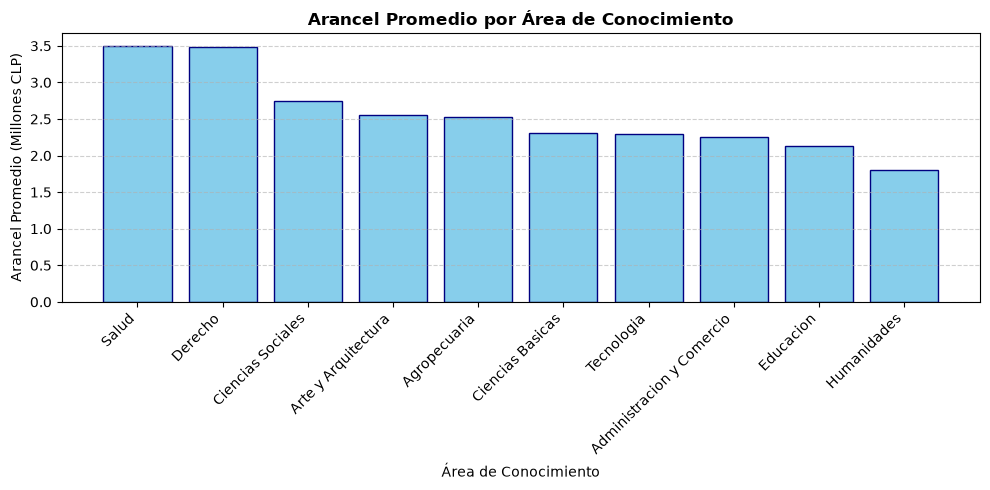

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df["VALOR ARANCEL (PESOS)"] = pd.to_numeric(
    df["VALOR ARANCEL (PESOS)"], errors="coerce"
)


mean_arancel = (
    df.groupby("AREA CONOCIMIENTO")["VALOR ARANCEL (PESOS)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    mean_arancel.index,
    mean_arancel.values / 1e6,
    color="skyblue",
    edgecolor="navy",
)

plt.title(
    "Arancel Promedio por Área de Conocimiento", fontsize=12, fontweight="bold"
)
plt.xlabel("Área de Conocimiento")
plt.ylabel("Arancel Promedio (Millones CLP)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.tight_layout()
plt.show()

Sí, existen diferencias significativas en el costo de las carreras según el área de conocimiento a la que pertenecen. el criterio diseñado consistió en seleccionar la variable **Valor Arancel (Pesos)** como el indicador financiero clave del costo de las carreras, limpiando los datos para trabajar únicamente con registros válidos. Posteriormente, se agruparon las observaciones según su **Área de Conocimiento** y se calculó la **media aritmética (promedio)** del arancel de cada grupo para obtener un valor representativo general por disciplina. Finalmente, estos promedios se expresaron en millones de pesos CLP y se ordenaron de mayor a menor para jerarquizar las áreas, permitiendo comparar de forma clara y directa cuáles disciplinas presentan los costos de arancel más elevados mediante el gráfico de columnas.

¿Que influencia tiene la edad en el tipo de institucion a la que ingresean los estudiantes?

R:

Crear un grafico 

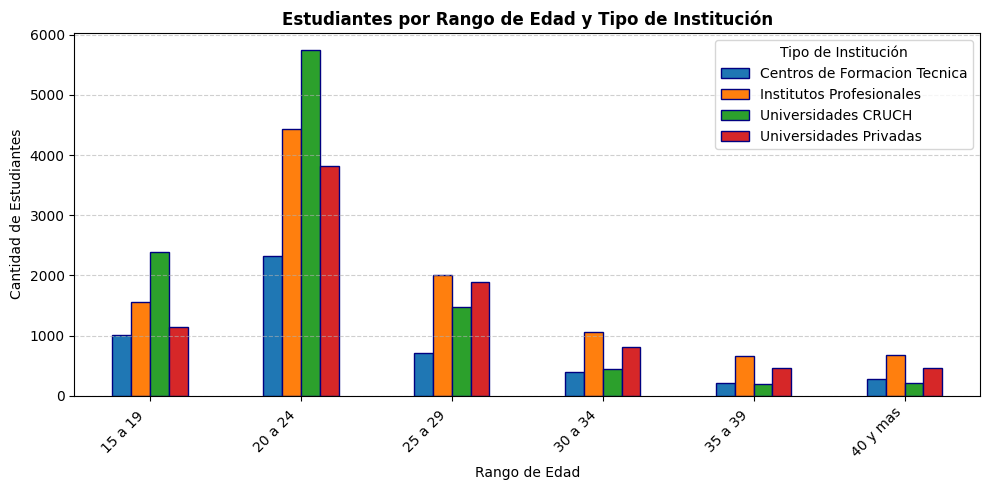

In [ ]:


tabla_agrupada = df.groupby(["RANGO EDAD", "TIPO DE INSTITUCION"]).size().unstack()


tabla_agrupada.plot(
    kind="bar", 
    figsize=(10, 5), 
    edgecolor="navy"
)

plt.title("Estudiantes por Rango de Edad y Tipo de Institución", fontsize=12, fontweight="bold")
plt.xlabel("Rango de Edad")
plt.ylabel("Cantidad de Estudiantes")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Tipo de Institución")
plt.tight_layout()
plt.show()

R: Sí, la edad marca una gran diferencia. Si miramos las barras la gran mayoría de los cabros más jóvenes (entre 15 y 24 años) se concentra en el CRUCH, buscando las carreras tradicionales post-educación media.
Pero a partir de los 25 años la tendencia cambia súper rápido. Ahí los Institutos Profesionales  lideran las matrículas. Conversando esto en el grupo creemos que tiene todo el sentido, porque los estudiantes de mayor edad generalmente ya están insertos en el mundo laboral y necesitan opciones más flexibles carreras técnicas más cortas o estudiar de noche.

¿Existen carreras con aranceles marcadamente más caros en la región?

R:

Para responder esto calculamos en Python el límite de datos atípicos usando los cuartiles del arancel. El corte nos da en 6 707 500 CLP, así que cualquier carrera que cobre sobre ese valor se considera fuera de lo normal (muy cara).


In [ ]:
# Cálculo de límites de Tukey para valores atípicos
q1 = df['VALOR ARANCEL (PESOS)'].quantile(0.25)
q3 = df['VALOR ARANCEL (PESOS)'].quantile(0.75)
limite_outlier = q3 + 1.5 * (q3 - q1)

print(f'Límite de arancel atípico superior: ${limite_outlier:,.0f} CLP')

# Programas que superan el umbral ordenados por arancel medio
cols_agrupacion = ['NOMBRE CARRERA', 'NOMBRE DE INSTITUCION', 'AREA CONOCIMIENTO']
carreras_outliers = (
    df[df['VALOR ARANCEL (PESOS)'] >= limite_outlier]
    .groupby(cols_agrupacion)['VALOR ARANCEL (PESOS)']
    .agg(Matriculados='count', Arancel_Anual='mean')
    .round(0)
    .sort_values(by='Arancel_Anual', ascending=False)
    .reset_index()
)

carreras_outliers


Límite de Arancel Atípico Superior (Tukey): $6,707,500 CLP


,NOMBRE CARRERA,NOMBRE DE INSTITUCION,AREA CONOCIMIENTO,Matriculados,Arancel_Anual
4,POSTITULO DE ESPECIALIZACION EN CIRUGIA,UNIVERSIDAD SAN SEBASTIAN,Salud,11,7725000.0
7,POSTITULO DE ESPECIALIZACION MEDICA EN ANESTES...,UNIVERSIDAD SAN SEBASTIAN,Salud,5,7725000.0
3,POSTITULO DE ESPECIALIDAD MEDICA EN GERIATRIA,UNIVERSIDAD SAN SEBASTIAN,Salud,2,7725000.0
6,POSTITULO DE ESPECIALIZACION EN PEDIATRIA,UNIVERSIDAD SAN SEBASTIAN,Salud,7,7725000.0
5,POSTITULO DE ESPECIALIZACION EN MEDICINA INTERNA,UNIVERSIDAD SAN SEBASTIAN,Salud,12,7725000.0
8,POSTITULO DE ESPECIALIZACION MEDICA EN MEDICIN...,UNIVERSIDAD SAN SEBASTIAN,Salud,8,7725000.0
1,MEDICINA,UNIVERSIDAD SAN SEBASTIAN,Salud,444,7679600.0
0,MAGISTER EN GESTION DE PERSONAS Y DESARROLLO D...,UNIVERSIDAD SAN SEBASTIAN,Administracion y Comercio,10,6900000.0
2,ODONTOLOGIA,UNIVERSIDAD SAN SEBASTIAN,Salud,288,6809700.0


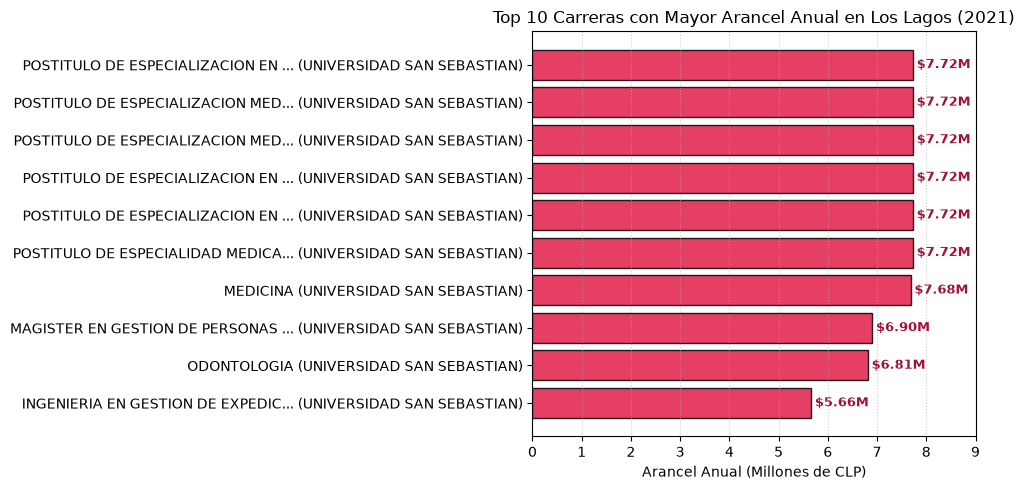

In [ ]:
# Top 10 carreras y programas con mayor arancel promedio (en millones de CLP)
top10 = (
    df.groupby(['NOMBRE CARRERA', 'NOMBRE DE INSTITUCION'])['VALOR ARANCEL (PESOS)']
    .mean()
    .nlargest(10)
    .sort_values(ascending=True) / 1e6
)

etiquetas = [f'{c[:30]}... ({inst})' if len(c) > 30 else f'{c} ({inst})' for c, inst in top10.index]

plt.figure(figsize=(10, 5))
barras = plt.barh(etiquetas, top10.values, color='#e11d48', edgecolor='black', alpha=0.85)

for b in barras:
    w = b.get_width()
    plt.text(w + 0.08, b.get_y() + b.get_height() / 2, f'${w:.2f}M', va='center', fontsize=9, fontweight='bold', color='#9f1239')

plt.xlim(0, 9.0)
plt.xlabel('Arancel Anual (Millones de CLP)')
plt.title('Top 10 carreras con mayor arancel anual en Los Lagos (2021)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


R: Sí, existen carreras con aranceles mucho más caros en la región.

Si miramos los resultados y el gráfico, todas las carreras que superan el límite de 6 707 500 CLP son de la Universidad San Sebastián en Puerto Montt:
- Los postítulos médicos (Cirugía, Pediatría, Anestesiología, etc.) lideran con 7 725 000 CLP.
- La carrera de Medicina cuesta 7 679 600 CLP al año, con 444 alumnos matriculados.
- También pasan el límite el Magíster en Gestión de Personas (6 900 000 CLP) y Odontología (6 809 700 CLP).

Estudiar Medicina o carreras de la salud sale 3,6 veces más caro que la mediana regional (2 160 000 CLP). Esto pasa principalmente por los costos de los campos clínicos y laboratorios, y porque al ser la única opción privada con estas carreras en la zona, la gente prefiere pagar acá antes que irse a estudiar a Santiago o Concepción.


# Datos para la precentacion

## 1-Total de matriculados , cantidad de carreras y intituciones

In [6]:
import pandas as pd

df = pd.read_excel("14_MATRICULAS_ED_SUPERIOR_LOS_LAGOS_2021.xlsx")

total_filas = len(df)
total_carreras = df["NOMBRE CARRERA"].nunique()
total_instituciones = df["NOMBRE DE INSTITUCION"].nunique()

print("Total de matriculados:", total_filas)
print("Total de carreras:", total_carreras)
print("Total de instituciones:", total_instituciones)

Total de matriculados: 34372
Total de carreras: 277
Total de instituciones: 16


In [9]:

sedes = df.groupby(["NOMBRE DE INSTITUCION", "TIPO DE INSTITUCION"])["COMUNA SEDE"].unique()
print(sedes)


por_comuna = df.groupby("COMUNA SEDE")["NOMBRE DE INSTITUCION"].nunique()
print(por_comuna.sort_values(ascending=False))

NOMBRE DE INSTITUCION                    TIPO DE INSTITUCION         
CFT DE LA REGION DE LOS LAGOS            Centros de Formacion Tecnica                             [Llanquihue]
CFT INACAP                               Centros de Formacion Tecnica                   [Puerto Montt, Osorno]
CFT IPROSEC                              Centros de Formacion Tecnica                                 [Osorno]
CFT SANTO TOMAS                          Centros de Formacion Tecnica                   [Puerto Montt, Osorno]
IP AGRARIO ADOLFO MATTHEI                Institutos Profesionales                                     [Osorno]
IP AIEP                                  Institutos Profesionales               [Puerto Montt, Castro, Osorno]
IP DEL VALLE CENTRAL                     Institutos Profesionales                               [Puerto Montt]
IP DUOC UC                               Institutos Profesionales                               [Puerto Montt]
IP INACAP                                I